In [61]:
import numpy as np
import pandas as pd
import torch

In [62]:
df = pd.read_csv("./wandb_export.csv")
# Filter complete runs with all fold scores
df_complete = df[df[[f'Score_{i}' for i in range(5)]].notna().all(axis=1)].copy()
print(f"Complete runs: {len(df_complete)}")

# Extract binary features from run names
def extract_features(name):
    """Extract one-hot encoded features from run name"""
    name_lower = name.lower()
    
    # Backbone: effnetb3, dinov3
    backbone_effnetb3 = 1 if 'effnetb3' in name_lower or 'effnet' in name_lower else 0
    backbone_dinov3 = 1 if 'dinov3' in name_lower else 0
    
    # Train type: ft (finetune), mlae, frozen
    train_ft = 1 if name_lower.startswith('ft-') or 'finetune' in name_lower else 0
    train_mlae = 1 if 'mlae' in name_lower else 0
    train_frozen = 1 if 'frozen' in name_lower else 0
    
    # Head type: linear, autogluon
    head_linear = 1 if 'linear' in name_lower else 0
    head_autogluon = 1 if 'autogluon' in name_lower else 0
    
    # If no head specified, assume linear for ft/mlae, check for autogluon in frozen
    if head_linear == 0 and head_autogluon == 0:
        if train_ft or train_mlae:
            head_linear = 1
        # else keep both 0 or handle as needed
    
    # Loss type: smooth, competition
    loss_smooth = 1 if 'smooth' in name_lower else 0
    loss_competition = 1 if 'competition' in name_lower else 0
    
    # If no loss specified, assume smooth (or adjust based on your defaults)
    if loss_smooth == 0 and loss_competition == 0:
        loss_smooth = 1  # default to smooth
    
    return [backbone_effnetb3, backbone_dinov3, train_ft, train_mlae, train_frozen, 
            head_linear, head_autogluon, loss_smooth, loss_competition]

df_complete['features'] = df_complete['Name'].apply(extract_features)

# Display parsed features
feature_names = ['backbone_effnetb3', 'backbone_dinov3', 'train_ft', 'train_mlae', 
                'train_frozen', 'head_linear', 'head_autogluon', 'loss_smooth', 'loss_competition']
features_df = pd.DataFrame(df_complete['features'].tolist(), columns=feature_names, index=df_complete.index)
print("\nParsed features:")
print(pd.concat([df_complete[['Name']], features_df], axis=1))

df_complete.head()

Complete runs: 4

Parsed features:
                              Name  backbone_effnetb3  backbone_dinov3  \
0  ft-effnetb3-cv-competition-loss                  1                0   
1                   ft-effnetb3-cv                  1                0   
2                   mlae-dinov3-cv                  0                1   
3       frozen-dinov3-autogluon-cv                  0                1   

   train_ft  train_mlae  train_frozen  head_linear  head_autogluon  \
0         1           0             0            1               0   
1         1           0             0            1               0   
2         0           1             0            1               0   
3         0           0             1            0               1   

   loss_smooth  loss_competition  
0            0                 1  
1            1                 0  
2            1                 0  
3            1                 0  


,Name,State,Created,Runtime,OOF Score,Score_0,Score_1,Score_2,Score_3,Score_4,features
0,ft-effnetb3-cv-competition-loss,finished,2025-11-28T09:51:52.000Z,6809,0.688687,0.722240,0.638638,0.639077,0.652300,0.603401,"[1, 0, 1, 0, 0, 1, 0, 0, 1]"
1,ft-effnetb3-cv,finished,2025-11-28T08:12:12.000Z,5948,0.613319,0.717202,0.677953,0.454870,0.607072,0.447992,"[1, 0, 1, 0, 0, 1, 0, 1, 0]"
2,mlae-dinov3-cv,finished,2025-11-27T14:36:03.000Z,55544,0.664892,0.754999,0.734693,0.557519,0.622956,0.527615,"[0, 1, 0, 1, 0, 1, 0, 1, 0]"
3,frozen-dinov3-autogluon-cv,finished,2025-11-27T09:33:55.000Z,18110,0.667801,0.665060,0.661206,0.712749,0.538222,0.495295,"[0, 1, 0, 0, 1, 0, 1, 1, 0]"


In [63]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

class FoldScoreModel(nn.Module):
    """
    Model where:
    - Each fold score = linear map (w/ bias) from features
    - Regularization encourages similar weights/biases across folds
    - OOF score = weighted average of fold scores (weights regularized to ~0.2)
    """
    def __init__(self, n_features, n_folds=5):
        super().__init__()
        self.n_folds = n_folds
        
        # Separate linear layers for each fold
        self.fold_layers = nn.ModuleList([
            nn.Linear(n_features, 1) for _ in range(n_folds)
        ])
        
        # Weights for combining fold scores into OOF (should sum to 1)
        self.oof_weights = nn.Parameter(torch.ones(n_folds) / n_folds)
        
    def forward(self, x):
        """
        Args:
            x: (batch_size, n_features)
        Returns:
            fold_scores: (batch_size, n_folds)
            oof_scores: (batch_size,)
        """
        # Get predictions from each fold
        fold_scores = torch.stack([layer(x).squeeze(-1) for layer in self.fold_layers], dim=1)
        
        # Normalize oof_weights to sum to 1
        weights = torch.softmax(self.oof_weights, dim=0)
        
        # Compute OOF as weighted average
        oof_scores = (fold_scores.detach() * weights).sum(dim=1)
        
        return fold_scores, oof_scores
    
    def regularization_loss(self, lambda_weight_sim, lambda_bias_sim, lambda_oof_uniform):
        """
        Regularization terms:
        - lambda_weight_sim: encourages similar weights across folds
        - lambda_bias_sim: encourages similar biases across folds  
        - lambda_oof_uniform: encourages OOF weights close to uniform (0.2 each)
        """
        reg_loss = 0.0
        
        # Weight similarity across folds
        weights = torch.stack([layer.weight for layer in self.fold_layers])  # (n_folds, 1, n_features)
        weight_mean = weights.mean(dim=0, keepdim=True)
        reg_loss += lambda_weight_sim * ((weights - weight_mean) ** 2).mean()
        
        # Bias similarity across folds
        biases = torch.stack([layer.bias for layer in self.fold_layers])  # (n_folds,)
        bias_mean = biases.mean(dim=0, keepdim=True)
        reg_loss += lambda_bias_sim * ((biases - bias_mean) ** 2).mean()
        
        # OOF weights close to uniform
        uniform_weights = torch.ones_like(self.oof_weights) / self.n_folds
        oof_weights_normalized = torch.softmax(self.oof_weights, dim=0)
        reg_loss += lambda_oof_uniform * ((oof_weights_normalized - uniform_weights) ** 2).mean()
        
        return reg_loss

print("Model class defined")

Model class defined


In [64]:
def train_model(X, fold_scores, oof_scores, lambda_weight_sim=0.01, lambda_bias_sim=0.01, 
                lambda_oof_uniform=0.1, epochs=5000, lr=0.01, verbose=True,
                fold_mask=None, oof_mask=None):
    """
    Train the model with given regularization parameters
    
    Args:
        X: (n_samples, n_features) feature matrix
        fold_scores: (n_samples, n_folds) fold scores
        oof_scores: (n_samples,) OOF scores
        lambda_*: regularization parameters
        epochs: number of training epochs
        lr: learning rate
        fold_mask: (n_samples, n_folds) boolean mask, True=use for training, False=masked
        oof_mask: (n_samples,) boolean mask, True=use for training, False=masked
    
    Returns:
        model: trained model
        losses: list of training losses
    """
    n_samples, n_features = X.shape
    n_folds = fold_scores.shape[1]
    
    # Convert to tensors
    X_tensor = torch.FloatTensor(X)
    fold_scores_tensor = torch.FloatTensor(fold_scores)
    oof_scores_tensor = torch.FloatTensor(oof_scores)
    
    # Convert masks to tensors if provided
    if fold_mask is not None:
        fold_mask_tensor = torch.FloatTensor(fold_mask.astype(float))
    else:
        fold_mask_tensor = None
    
    if oof_mask is not None:
        oof_mask_tensor = torch.FloatTensor(oof_mask.astype(float))
    else:
        oof_mask_tensor = None
    
    # Initialize model
    model = FoldScoreModel(n_features, n_folds)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    losses = []
    
    for epoch in range(epochs):
        optimizer.zero_grad()
        
        # Forward pass
        pred_fold_scores, pred_oof_scores = model(X_tensor)
        
        # Data loss (MSE) with masking support
        if fold_mask_tensor is not None:
            # Only compute loss on non-masked cells
            fold_loss = ((pred_fold_scores - fold_scores_tensor) ** 2 * fold_mask_tensor).sum() / fold_mask_tensor.sum()
        else:
            fold_loss = ((pred_fold_scores - fold_scores_tensor) ** 2).mean()
        
        if oof_mask_tensor is not None:
            # Only compute loss on non-masked cells
            oof_loss = ((pred_oof_scores - oof_scores_tensor) ** 2 * oof_mask_tensor).sum() / oof_mask_tensor.sum()
        else:
            oof_loss = ((pred_oof_scores - oof_scores_tensor) ** 2).mean()
        
        data_loss = fold_loss + oof_loss
        
        # Regularization loss
        reg_loss = model.regularization_loss(lambda_weight_sim, lambda_bias_sim, lambda_oof_uniform)
        
        # Total loss
        loss = data_loss + reg_loss
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
        
        if verbose and (epoch + 1) % 500 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f} (Data: {data_loss.item():.6f}, Reg: {reg_loss.item():.6f})")
    
    return model, losses

print("Training function defined")

Training function defined


In [65]:
def masked_cell_cv(X, fold_scores, oof_scores, n_masks=20, mask_ratio=0.2, 
                   lambda_weight_sim=0.01, lambda_bias_sim=0.01, 
                   lambda_oof_uniform=0.1, epochs=5000, lr=0.01):
    """
    Cross-validation by randomly masking individual cells (fold scores and OOF scores)
    Trains the actual FoldScoreModel on non-masked cells and evaluates on masked cells
    
    Args:
        X: (n_samples, n_features) feature matrix
        fold_scores: (n_samples, n_folds) fold scores
        oof_scores: (n_samples,) OOF scores
        n_masks: number of different random masks to try
        mask_ratio: fraction of cells to mask in each trial
        lambda_*: regularization parameters for FoldScoreModel
        
    Returns:
        mask_errors: list of MSE for each masked trial
        mean_mse: average MSE across all trials
        std_mse: standard deviation of MSE
    """
    n_samples, n_folds = fold_scores.shape
    total_cells = n_samples * n_folds + n_samples  # fold scores + OOF scores
    n_mask_cells = int(total_cells * mask_ratio)
    
    mask_errors = []
    
    print(f"Running masked cell CV with {n_masks} trials, masking {mask_ratio*100:.1f}% of cells...")
    print(f"  Total cells: {total_cells} ({n_samples}x{n_folds} fold + {n_samples} OOF)")
    print(f"  Cells masked per trial: {n_mask_cells}\n")
    
    for trial in range(n_masks):
        # Determine how many fold vs OOF cells to mask
        n_mask_fold = int(n_mask_cells * (n_samples * n_folds) / total_cells)
        n_mask_oof = n_mask_cells - n_mask_fold
        
        # Create fold mask: True = use for training, False = masked (held out)
        fold_mask = np.ones((n_samples, n_folds), dtype=bool)
        all_fold_indices = [(i, j) for i in range(n_samples) for j in range(n_folds)]
        np.random.shuffle(all_fold_indices)
        masked_fold_indices = all_fold_indices[:n_mask_fold]
        
        for i, j in masked_fold_indices:
            fold_mask[i, j] = False
        
        # Create OOF mask: True = use for training, False = masked (held out)
        oof_mask = np.ones(n_samples, dtype=bool)
        all_oof_indices = list(range(n_samples))
        np.random.shuffle(all_oof_indices)
        masked_oof_indices = all_oof_indices[:n_mask_oof]
        
        for i in masked_oof_indices:
            oof_mask[i] = False
        
        # Train FoldScoreModel on non-masked cells
        model, _ = train_model(
            X, fold_scores, oof_scores,
            lambda_weight_sim=lambda_weight_sim,
            lambda_bias_sim=lambda_bias_sim,
            lambda_oof_uniform=lambda_oof_uniform,
            epochs=epochs,
            lr=lr,
            verbose=False,
            fold_mask=fold_mask,
            oof_mask=oof_mask
        )
        
        # Evaluate on masked cells
        with torch.no_grad():
            X_tensor = torch.FloatTensor(X)
            pred_fold_scores, pred_oof_scores = model(X_tensor)
            pred_fold_scores = pred_fold_scores.numpy()
            pred_oof_scores = pred_oof_scores.numpy()
        
        errors = []
        
        # Evaluate masked fold scores
        for i, j in masked_fold_indices:
            error = (pred_fold_scores[i, j] - fold_scores[i, j]) ** 2
            errors.append(error)
        
        # Evaluate masked OOF scores
        for i in masked_oof_indices:
            error = (pred_oof_scores[i] - oof_scores[i]) ** 2
            errors.append(error)
        
        trial_mse = np.mean(errors) if errors else 0.0
        mask_errors.append(trial_mse)
        
        print(f"  Trial {trial+1}/{n_masks}: MSE={trial_mse:.6f} ({len(errors)} cells masked)")
    
    mean_mse = np.mean(mask_errors)
    std_mse = np.std(mask_errors)
    
    print(f"\nMasked Cell CV Results:")
    print(f"  Mean MSE: {mean_mse:.6f} +/- {std_mse:.6f}")
    
    return mask_errors, mean_mse, std_mse

print("Masked cell CV function defined")

Masked cell CV function defined


In [66]:
def grid_search(X, fold_scores, oof_scores, 
               lambda_weight_sims=[0.001, 0.01, 0.1],
               lambda_bias_sims=[0.001, 0.01, 0.1],
               lambda_oof_uniforms=[0.01, 0.1, 1.0],
               n_masks=20, mask_ratio=0.2,
               epochs=3000, lr=0.01):
    """
    Grid search over regularization parameters using masked cell CV
    
    Returns:
        results: DataFrame with parameters and CV MSE
        best_params: dict with best regularization parameters
    """
    results = []
    best_mse = float('inf')
    best_params = None
    
    total_configs = len(lambda_weight_sims) * len(lambda_bias_sims) * len(lambda_oof_uniforms)
    config_num = 0
    
    print(f"Grid search over {total_configs} configurations...\n")
    
    for lws in lambda_weight_sims:
        for lbs in lambda_bias_sims:
            for lou in lambda_oof_uniforms:
                config_num += 1
                print(f"[{config_num}/{total_configs}] Testing lambda_weight_sim={lws}, lambda_bias_sim={lbs}, lambda_oof_uniform={lou}")
                
                _, mean_mse, std_mse = masked_cell_cv(
                    X, fold_scores, oof_scores,
                    n_masks=n_masks,
                    mask_ratio=mask_ratio,
                    lambda_weight_sim=lws,
                    lambda_bias_sim=lbs,
                    lambda_oof_uniform=lou,
                    epochs=epochs,
                    lr=lr
                )
                
                result = {
                    'lambda_weight_sim': lws,
                    'lambda_bias_sim': lbs,
                    'lambda_oof_uniform': lou,
                    'mean_mse': mean_mse,
                    'std_mse': std_mse
                }
                results.append(result)
                
                if mean_mse < best_mse:
                    best_mse = mean_mse
                    best_params = result.copy()
                
                print(f"  MSE: {mean_mse:.6f} +/- {std_mse:.6f}\n")
    
    print(f"\n{'='*60}")
    print("BEST PARAMETERS:")
    print(f"  lambda_weight_sim: {best_params['lambda_weight_sim']}")
    print(f"  lambda_bias_sim: {best_params['lambda_bias_sim']}")
    print(f"  lambda_oof_uniform: {best_params['lambda_oof_uniform']}")
    print(f"  MSE: {best_params['mean_mse']:.6f} +/- {best_params['std_mse']:.6f}")
    print(f"{'='*60}\n")
    
    return pd.DataFrame(results), best_params

print("Grid search function defined")

Grid search function defined


In [67]:
# Prepare data for modeling
X = np.array(df_complete['features'].tolist())
fold_scores = df_complete[[f'Score_{i}' for i in range(5)]].values
oof_scores = df_complete['OOF Score'].values

print(f"Data shape:")
print(f"  X: {X.shape}")
print(f"  fold_scores: {fold_scores.shape}")
print(f"  oof_scores: {oof_scores.shape}")
print(f"\nFeature matrix:")
print(X)

Data shape:
  X: (4, 9)
  fold_scores: (4, 5)
  oof_scores: (4,)

Feature matrix:
[[1 0 1 0 0 1 0 0 1]
 [1 0 1 0 0 1 0 1 0]
 [0 1 0 1 0 1 0 1 0]
 [0 1 0 0 1 0 1 1 0]]


Training baseline model...


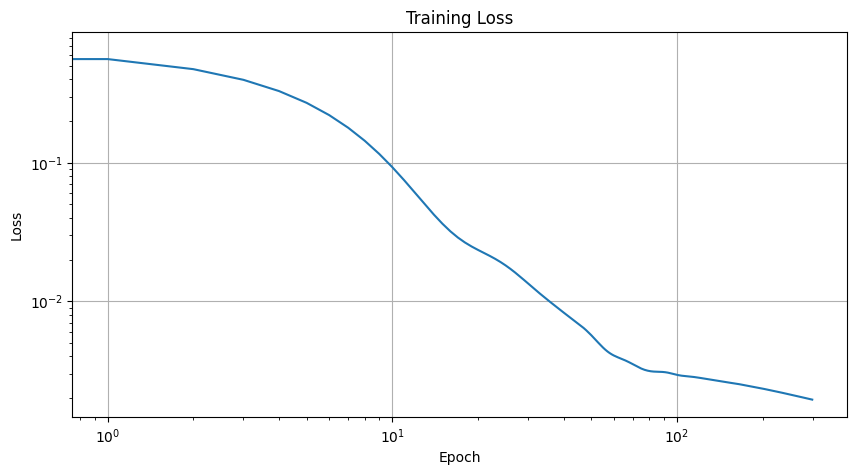


Learned OOF weights: [0.21410584 0.20842879 0.19900167 0.19573529 0.18272842]
Expected uniform: [0.2 0.2 0.2 0.2 0.2]


In [68]:
# Quick test with baseline regularization
print("Training baseline model...")
model_baseline, losses = train_model(
    X, fold_scores, oof_scores,
    lambda_weight_sim=0.1,
    lambda_bias_sim=0.001, 
    lambda_oof_uniform=1,
    epochs=300,
    lr=0.01,
    verbose=True
)

# Visualize training
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.yscale('log')
plt.xscale('log')
plt.grid(True)
plt.show()

# Show learned OOF weights
with torch.no_grad():
    oof_weights = torch.softmax(model_baseline.oof_weights, dim=0).numpy()
    print(f"\nLearned OOF weights: {oof_weights}")
    print(f"Expected uniform: {np.ones(5) / 5}")

In [69]:
# Run grid search with masked cell CV (uncomment to run)
# grid_results, best_params = grid_search(
#     X, fold_scores, oof_scores,
#     lambda_weight_sims=[0.001, 0.01, 0.1],
#     lambda_bias_sims=[0.001, 0.01, 0.1],
#     lambda_oof_uniforms=[0.01, 0.1, 1.0],
#     n_masks=5,
#     mask_ratio=0.2,
#     epochs=300,
#     lr=0.01
# )

# Display results sorted by performance
# print(grid_results.sort_values('mean_mse'))

In [70]:
# Query model for new configurations
def predict_new_config(model, feature_dict):
    """
    Predict scores for a new configuration
    
    Args:
        model: trained FoldScoreModel
        feature_dict: dict with feature names as keys and binary values
                     e.g., {'backbone_effnetb3': 1, 'backbone_dinov3': 0, ...}
    
    Returns:
        fold_scores: predicted scores for each fold
        oof_score: predicted OOF score
    """
    # Construct feature vector in correct order
    feature_order = ['backbone_effnetb3', 'backbone_dinov3', 'train_ft', 
                    'train_mlae', 'train_frozen', 'head_linear', 'head_autogluon',
                    'loss_smooth', 'loss_competition']
    x = np.array([feature_dict[f] for f in feature_order]).reshape(1, -1)
    
    with torch.no_grad():
        x_tensor = torch.FloatTensor(x)
        pred_fold, pred_oof = model(x_tensor)
        
    fold_scores = pred_fold.numpy()[0]
    oof_score = pred_oof.numpy()[0]
    
    return fold_scores, oof_score

# Example: Query for new configurations
print("Querying model for new configurations:\n")

# Example 1: effnetb3 + mlae + linear + smooth loss
config1 = {
    'backbone_effnetb3': 1, 'backbone_dinov3': 0,
    'train_ft': 1, 'train_mlae': 0, 'train_frozen': 0,
    'head_linear': 1, 'head_autogluon': 0,
    'loss_smooth': 0, 'loss_competition': 1
}
fold_scores1, oof1 = predict_new_config(model_baseline, config1)
print(f"  Predicted fold scores: {fold_scores1}")
print(f"  Predicted OOF: {oof1:.6f}\n")


# Example 1: effnetb3 + mlae + linear + smooth loss
config1 = {
    'backbone_effnetb3': 0, 'backbone_dinov3': 1,
    'train_ft': 0, 'train_mlae': 1, 'train_frozen': 0,
    'head_linear': 1, 'head_autogluon': 0,
    'loss_smooth': 0, 'loss_competition': 1
}
fold_scores1, oof1 = predict_new_config(model_baseline, config1)
print(f"  Predicted fold scores: {fold_scores1}")
print(f"  Predicted OOF: {oof1:.6f}\n")

Querying model for new configurations:

  Predicted fold scores: [0.7255893 0.6431646 0.6368085 0.6526799 0.5974872]
  Predicted OOF: 0.653063

  Predicted fold scores: [0.7684506  0.70170623 0.73793805 0.6700013  0.67049074]
  Predicted OOF: 0.711297



In [71]:
# Inspect learned model parameters
def inspect_model(model):
    """Display learned weights and biases for each fold"""
    feature_names = ['backbone_effnetb3', 'backbone_dinov3', 'train_ft', 
                    'train_mlae', 'train_frozen', 'head_linear', 'head_autogluon',
                    'loss_smooth', 'loss_competition']
    
    print("Learned Parameters:\n")
    print("="*80)
    
    # Display weights for each fold
    with torch.no_grad():
        for fold_idx, layer in enumerate(model.fold_layers):
            print(f"\nFold {fold_idx}:")
            print(f"  Bias: {layer.bias.item():.6f}")
            print("  Weights:")
            for feat_name, weight in zip(feature_names, layer.weight[0]):
                print(f"    {feat_name:20s}: {weight.item():8.6f}")
        
        # Display OOF weights
        oof_weights = torch.softmax(model.oof_weights, dim=0).numpy()
        print("\nOOF Fold Weights:")
        for i, w in enumerate(oof_weights):
            print(f"  Fold {i}: {w:.6f}")
        print(f"  (Uniform would be: {1/len(oof_weights):.6f})")
    
    print("="*80)

inspect_model(model_baseline)

Learned Parameters:


Fold 0:
  Bias: 0.340085
  Weights:
    backbone_effnetb3   : 0.109673
    backbone_dinov3     : 0.190569
    train_ft            : -0.021303
    train_mlae          : -0.059338
    train_frozen        : 0.115278
    head_linear         : 0.322136
    head_autogluon      : 0.056510
    loss_smooth         : -0.037105
    loss_competition    : -0.025002

Fold 1:
  Bias: 0.424893
  Weights:
    backbone_effnetb3   : 0.013195
    backbone_dinov3     : 0.254005
    train_ft            : 0.150550
    train_mlae          : -0.031719
    train_frozen        : -0.020440
    head_linear         : 0.095656
    head_autogluon      : 0.014795
    loss_smooth         : -0.009300
    loss_competition    : -0.041129

Fold 2:
  Bias: 0.253854
  Weights:
    backbone_effnetb3   : -0.005463
    backbone_dinov3     : 0.196520
    train_ft            : 0.104538
    train_mlae          : 0.003685
    train_frozen        : 0.097745
    head_linear         : 0.061196
    head_autogluon 